In [3]:
!pip install pandas



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd

df = pd.read_csv("customer_shopping_behavior.csv")

In [2]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [4]:
df.describe(include = "all")

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [5]:
df["Review Rating"] = df.groupby("Category")['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [6]:
df.isna().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [7]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ","_")

In [8]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [9]:
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [10]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [11]:
#create new column for age group
labels= ['Young Adult', 'Adult', 'Middle-Age', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels = labels)

In [12]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-Age
1,19,Young Adult
2,50,Middle-Age
3,21,Young Adult
4,45,Middle-Age
5,46,Middle-Age
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-Age


In [13]:
# Create new column for purchase_frequency_days

frequency_mapping = { 'Fortnightly':14,
                      'Weekly': 7, 
                      'Annually':365, 
                      'Quarterly': 90, 
                      'Monthly': 30, 
                      'Bi-Weekly':14, 
                      'Every 3 Months': 90}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [14]:
df[['frequency_of_purchases' , 'purchase_frequency_days']].head(20)
        

,frequency_of_purchases,purchase_frequency_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365
5,Weekly,7
6,Quarterly,90
7,Weekly,7
8,Annually,365
9,Quarterly,90


In [15]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [16]:
(df['promo_code_used'] == df['discount_applied']).all()

np.True_

In [17]:
df = df.drop('promo_code_used', axis = 1)

In [18]:
df.head(5)

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle-Age,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle-Age,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle-Age,365


In [19]:
!pip install psycopg2-binary sqlalchemy

In [35]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [20]:
from sqlalchemy import create_engine
import urllib.parse

#Connect to postgresql
username = "postgres"
password = "Postgresql@31"
#Encode the password to handle the '@' symbol
safe_password = urllib.parse.quote_plus(password)

host = "localhost"
port = "5432"
database = "customer_behaviour_analysis"

engine = create_engine(f"postgresql+psycopg2://{username}:{safe_password}@{host}:{port}/{database}")

#Load DataFrame into postgresql

table_name = "customer"
df.to_sql(table_name, engine, if_exists = "replace", index = False)

print(f"Data sucessfully loaded into table '{table_name}' in database '{database}'")

Data sucessfully loaded into table 'customer' in database 'customer_behaviour_analysis'


## Exploratory Data Analysis & Visualisations

Now that the data is cleaned and loaded into PostgreSQL, we explore key patterns
across seasons, gender, categories, and customer segments using visualizations.

In [23]:
pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 6.3 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 11.8 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 8.9 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 8.6 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.1 MB 7.6 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.1 MB 6.8 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 6.6 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.3 MB 2.4 MB/s eta 0:00:01
   ------------------ --------------------- 1.0/2.3 MB 2.8 MB/s eta 0:00:01
   --------------------------- ------------ 1.6/2.3 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 2.7 MB/s  0:00:00
   ----------------------------

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#ffffff',
    'axes.facecolor':   '#e8edf2',
    'axes.edgecolor':   '#0f3460',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.color':       '#ffffff',
    'grid.linewidth':   0.8,
    'font.family':      'DejaVu Sans',
})

TEAL   = '#00b4d8'
ORANGE = '#e94560'
PURPLE = '#7b2d8b'
GOLD   = '#f5a623'
ACCENT = '#0f3460'
COLORS = [TEAL, ORANGE, PURPLE, GOLD, ACCENT, '#2ecc71', '#e67e22']

print("Plotting setup complete.")


Matplotlib is building the font cache; this may take a moment.


Plotting setup complete.


### Seasonal Revenue

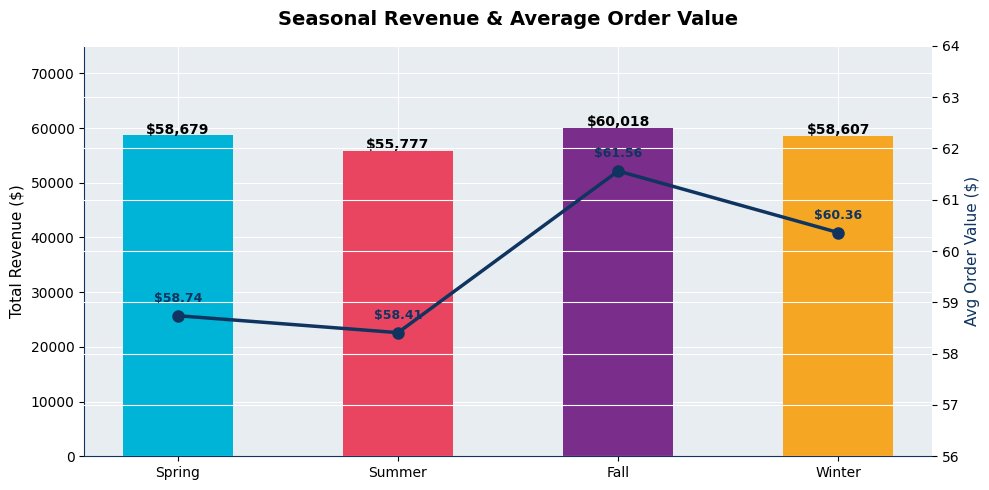

In [25]:
season_df = df.groupby('season')['purchase_amount'].agg(['sum', 'mean', 'count']).round(2)
season_df = season_df.reindex(['Spring', 'Summer', 'Fall', 'Winter'])

fig, ax1 = plt.subplots(figsize=(10, 5))
season_colors = [TEAL, ORANGE, PURPLE, GOLD]

bars = ax1.bar(season_df.index, season_df['sum'],
               color=season_colors, width=0.5, zorder=3)
ax1.set_ylabel('Total Revenue ($)', fontsize=11)
ax1.set_ylim(0, season_df['sum'].max() * 1.25)

for bar, val in zip(bars, season_df['sum']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(season_df.index, season_df['mean'], color=ACCENT,
         marker='o', linewidth=2.5, markersize=8, label='Avg Order ($)')
ax2.set_ylabel('Avg Order Value ($)', color=ACCENT, fontsize=11)
ax2.set_ylim(56, 64)
for x, y in zip(season_df.index, season_df['mean']):
    ax2.annotate(f'${y}', (x, y), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontsize=9,
                 color=ACCENT, fontweight='bold')

for spine in ax2.spines.values(): spine.set_visible(False)

plt.title('Seasonal Revenue & Average Order Value', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


### Gender Analysis

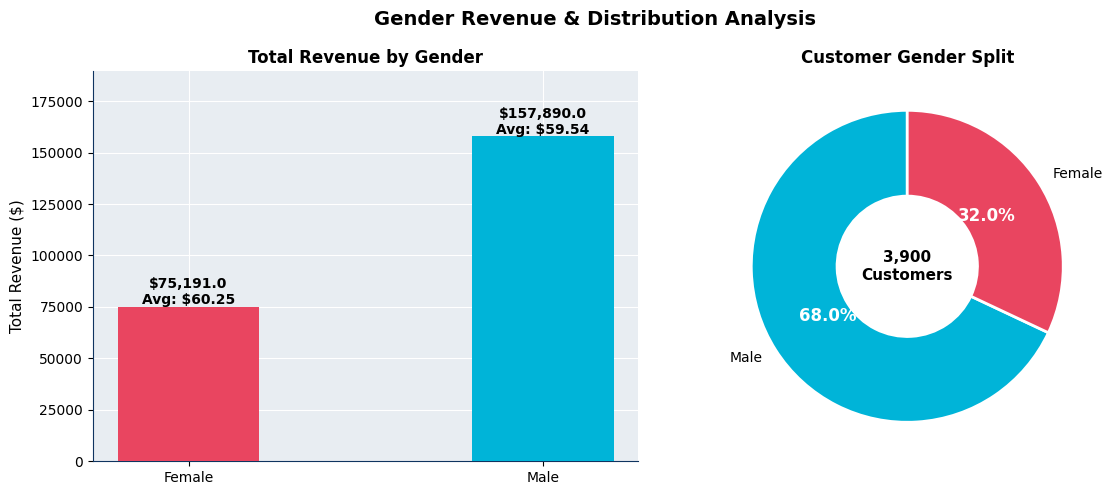

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

gender_df = df.groupby('gender')['purchase_amount'].agg(['sum', 'mean'])

# Revenue bar
bars = ax1.bar(gender_df.index, gender_df['sum'],
               color=[ORANGE, TEAL], width=0.4, zorder=3)
ax1.set_ylabel('Total Revenue ($)', fontsize=11)
ax1.set_title('Total Revenue by Gender', fontsize=12, fontweight='bold')
ax1.set_ylim(0, gender_df['sum'].max() * 1.2)
for bar, (idx, row) in zip(bars, gender_df.iterrows()):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000,
             f'${row["sum"]:,}\nAvg: ${row["mean"]:.2f}',
             ha='center', fontsize=10, fontweight='bold')

# Donut
sizes = df['gender'].value_counts()
wedges, texts, autotexts = ax2.pie(
    sizes, labels=sizes.index, autopct='%1.1f%%',
    colors=[TEAL, ORANGE], startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold'); at.set_color('white')
ax2.set_title('Customer Gender Split', fontsize=12, fontweight='bold')
ax2.text(0, 0, f'{len(df):,}\nCustomers', ha='center', va='center',
         fontsize=11, fontweight='bold')

plt.suptitle('Gender Revenue & Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



### Category Performance

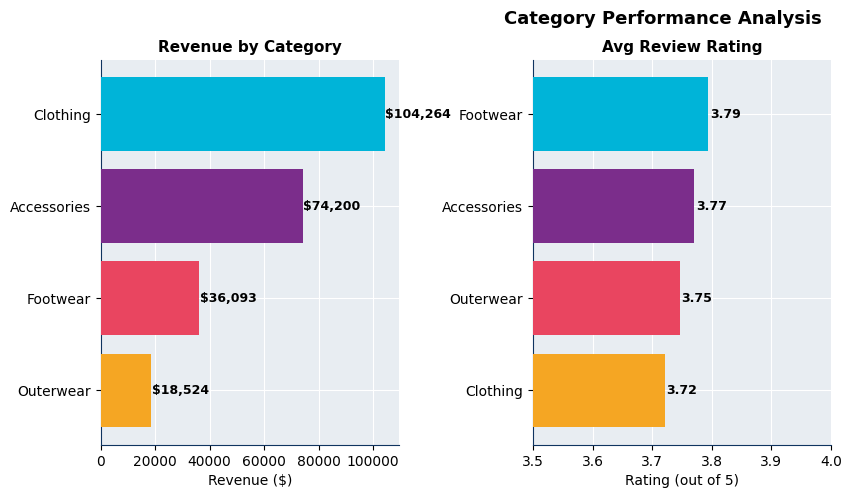

In [32]:
fig = plt.figure(figsize=(15, 5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.45)

cat_colors = [TEAL, PURPLE, ORANGE, GOLD]

# Revenue by category
ax1 = fig.add_subplot(gs[0])
cat_rev = df.groupby('category')['purchase_amount'].sum().sort_values(ascending=True)
ax1.barh(cat_rev.index, cat_rev.values, color=cat_colors[::-1], zorder=3)
ax1.set_title('Revenue by Category', fontsize=11, fontweight='bold')
ax1.set_xlabel('Revenue ($)')
for i, (idx, val) in enumerate(cat_rev.items()):
    ax1.text(val+200, i, f'${val:,}', va='center', fontsize=9, fontweight='bold')

# Avg rating by category
ax2 = fig.add_subplot(gs[1])
cat_rat = df.groupby('category')['review_rating'].mean().sort_values(ascending=True)
ax2.barh(cat_rat.index, cat_rat.values, color=cat_colors[::-1], zorder=3)
ax2.set_title('Avg Review Rating', fontsize=11, fontweight='bold')
ax2.set_xlabel('Rating (out of 5)')
ax2.set_xlim(3.5, 4.0)
for i, (idx, val) in enumerate(cat_rat.items()):
    ax2.text(val+0.003, i, f'{val:.2f}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Category Performance Analysis', fontsize=13, fontweight='bold')
plt.show()

### Payment Method & Shipping Behaviour

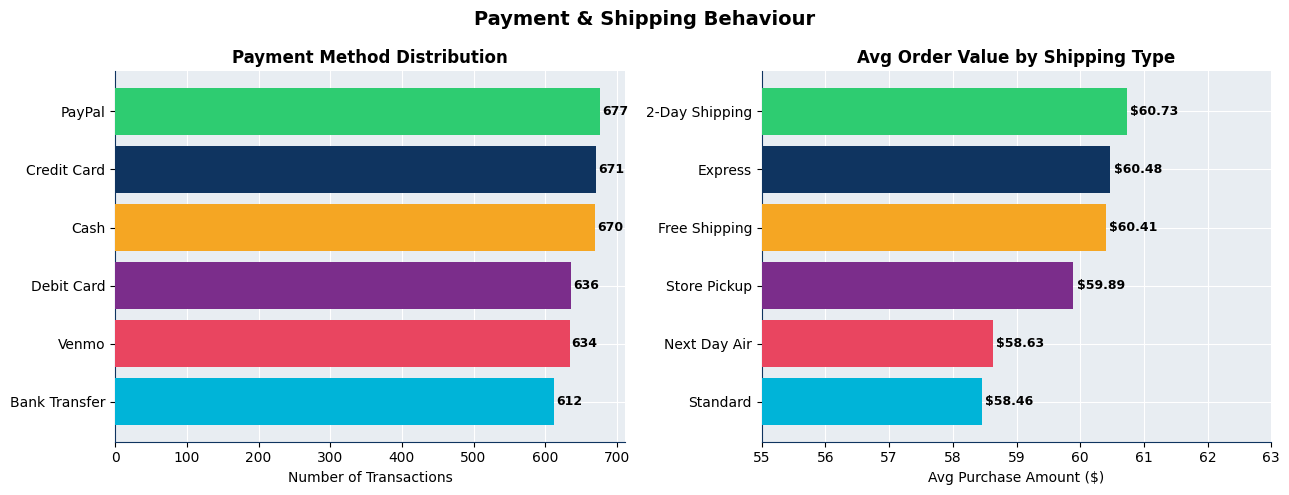

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Payment method count
pay = df['payment_method'].value_counts().sort_values(ascending=True)
ax1.barh(pay.index, pay.values, color=COLORS[:len(pay)], zorder=3)
ax1.set_title('Payment Method Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Transactions')
for i, (idx, val) in enumerate(pay.items()):
    ax1.text(val+3, i, f'{val:,}', va='center', fontsize=9, fontweight='bold')

# Avg spend by shipping type
ship = df.groupby('shipping_type')['purchase_amount'].mean().sort_values(ascending=True)
ax2.barh(ship.index, ship.values, color=COLORS[:len(ship)], zorder=3)
ax2.set_title('Avg Order Value by Shipping Type', fontsize=12, fontweight='bold')
ax2.set_xlabel('Avg Purchase Amount ($)')
ax2.set_xlim(55, 63)
for bar, val in zip(ax2.patches, ship.values):
    ax2.text(val+0.05, bar.get_y()+bar.get_height()/2,
             f'${val:.2f}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Payment & Shipping Behaviour', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Customer Segmentation & Loyalty

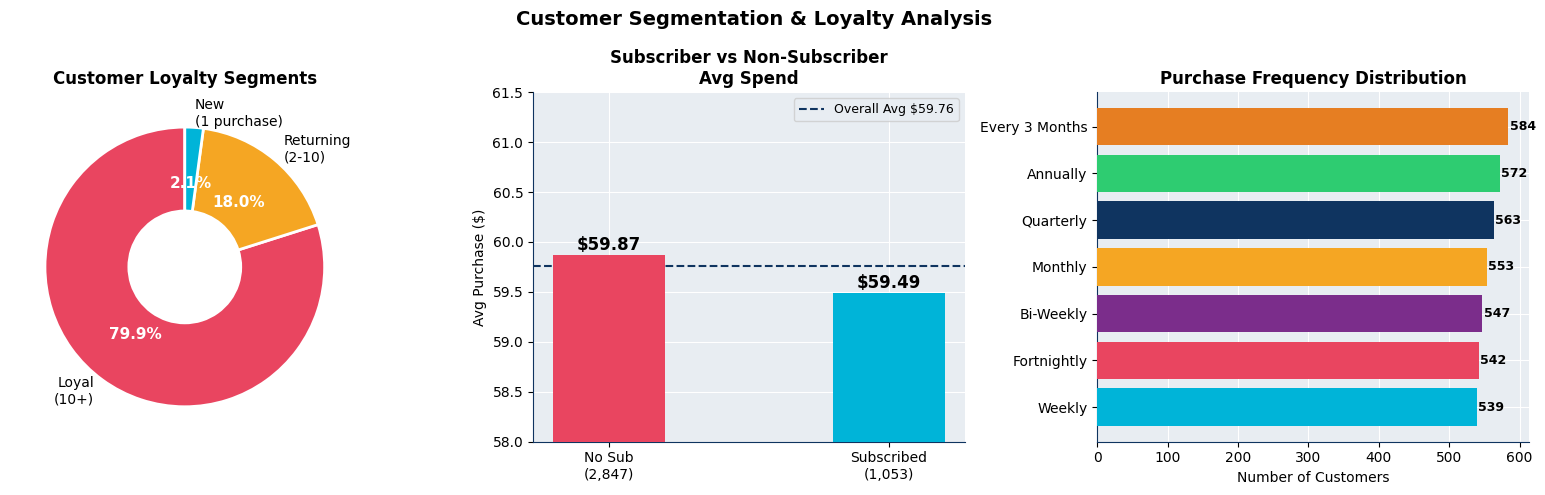

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loyalty donut
df['segment'] = df['previous_purchases'].apply(
    lambda x: 'New\n(1 purchase)' if x == 1
    else 'Returning\n(2-10)' if x <= 10
    else 'Loyal\n(10+)'
)
seg = df['segment'].value_counts()
wedges, texts, autotexts = axes[0].pie(
    seg, labels=seg.index, autopct='%1.1f%%',
    colors=[ORANGE, GOLD, TEAL], startangle=90,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2),
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold'); at.set_color('white')
axes[0].set_title('Customer Loyalty Segments', fontsize=12, fontweight='bold')

# Subscriber avg spend
sub = df.groupby('subscription_status')['purchase_amount'].agg(['mean','count'])
axes[1].bar(
    [f'No Sub\n({sub.loc["No","count"]:,})', f'Subscribed\n({sub.loc["Yes","count"]:,})'],
    sub['mean'], color=[ORANGE, TEAL], width=0.4, zorder=3
)
axes[1].set_ylim(58, 61.5)
axes[1].set_ylabel('Avg Purchase ($)')
axes[1].set_title('Subscriber vs Non-Subscriber\nAvg Spend', fontsize=12, fontweight='bold')
axes[1].axhline(y=59.76, color=ACCENT, linestyle='--', linewidth=1.5, label='Overall Avg $59.76')
axes[1].legend(fontsize=9)
for i, (idx, row) in enumerate(sub.iterrows()):
    axes[1].text(i, row['mean']+0.05, f'${row["mean"]:.2f}',
                 ha='center', fontsize=12, fontweight='bold')

# Purchase frequency
freq = df['frequency_of_purchases'].value_counts().sort_values(ascending=True)
axes[2].barh(freq.index, freq.values, color=COLORS[:len(freq)], zorder=3)
axes[2].set_title('Purchase Frequency Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of Customers')
for i, (idx, val) in enumerate(freq.items()):
    axes[2].text(val+2, i, f'{val:,}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Customer Segmentation & Loyalty Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Discount Impact & Top Products

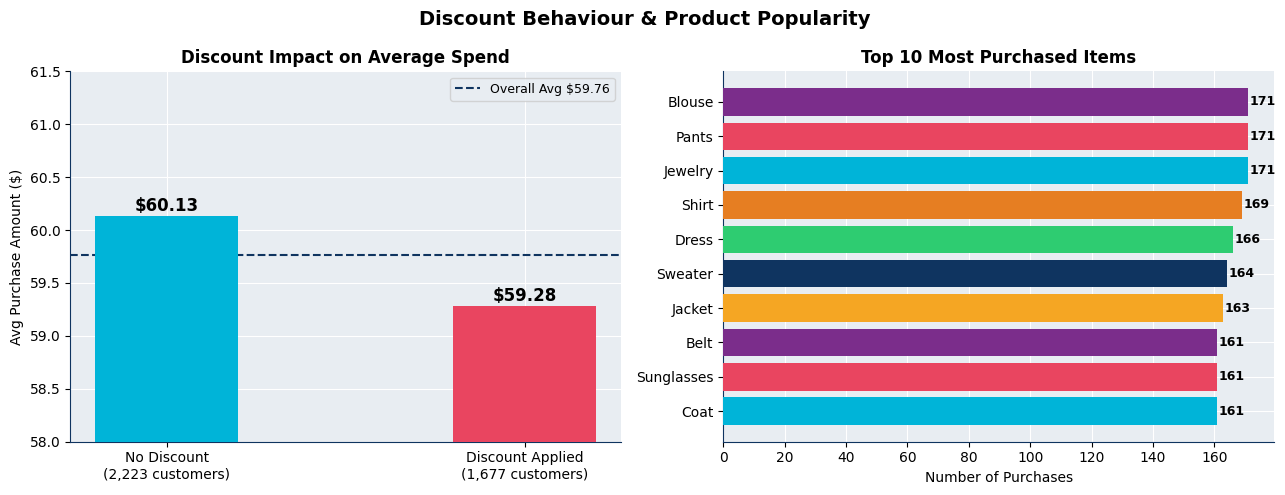

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Discount impact
disc = df.groupby('discount_applied')['purchase_amount'].agg(['mean','count'])
ax1.bar(
    [f'No Discount\n({disc.loc["No","count"]:,} customers)',
     f'Discount Applied\n({disc.loc["Yes","count"]:,} customers)'],
    disc['mean'], color=[TEAL, ORANGE], width=0.4, zorder=3
)
ax1.set_ylim(58, 61.5)
ax1.set_ylabel('Avg Purchase Amount ($)')
ax1.set_title('Discount Impact on Average Spend', fontsize=12, fontweight='bold')
ax1.axhline(y=59.76, color=ACCENT, linestyle='--', linewidth=1.5, label='Overall Avg $59.76')
ax1.legend(fontsize=9)
for i, (idx, row) in enumerate(disc.iterrows()):
    ax1.text(i, row['mean']+0.05, f'${row["mean"]:.2f}',
             ha='center', fontsize=12, fontweight='bold')

# Top 10 items
top_items = df['item_purchased'].value_counts().head(10).sort_values(ascending=True)
ax2.barh(top_items.index, top_items.values, color=COLORS[:10], zorder=3)
ax2.set_title('Top 10 Most Purchased Items', fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Purchases')
for i, (idx, val) in enumerate(top_items.items()):
    ax2.text(val+0.5, i, f'{val:,}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Discount Behaviour & Product Popularity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Summary of Key Findings

| Metric | Value |
|--------|-------|
| Total Revenue | $233,081 |
| Total Transactions | 3,900 |
| Average Order Value | $59.76 |
| Best Season (Revenue) | Fall ($60,018) |
| Best Season (Avg Order) | Fall ($61.56) |
| Male vs Female | 68% vs 32% of transactions |
| Top Category | Clothing (44.7% of revenue) |
| Loyal Customers | 80% (3,116 customers) |
| Discount-Resilient Customers | 839 (spent above avg with discount) |
| Top Payment Method | PayPal (677 transactions) |
| Top State | Montana ($5,784 revenue) |

All findings have been translated into SQL queries and visualised in the Power BI dashboard